# Verification: two-state gene expression noise (Munsky et al., 2012)

This notebook performs both checks required for curation:

1. **Model specification.** It runs the curated BNGL file with BioNetGen 2.9.3,
   checks the fresh fixed-seed SSA output against the committed reference, and
   compares the sampled distributions with an independently assembled finite-state
   projection (FSP) of each two-state promoter.
2. **Reported simulation data.** It compares both BioNetGen and the independent FSP
   with curves digitized from Fig. 2B of Munsky et al. (2012).

The paper reports distributions from an FSP calculation. The curated BNGL file
instead executes the source model's preferred direct Gillespie method over a long,
fixed-seed trajectory. Agreement is therefore assessed with distribution distances
and moment errors rather than pointwise trajectory error.

In [1]:
from pathlib import Path
import os
import shutil
import subprocess
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

MODEL_STEM = "two_state_gene_expression_noise_munsky2012"
cwd = Path.cwd().resolve()
MODEL_DIR = cwd if (cwd / f"{MODEL_STEM}.bngl").exists() else cwd / "models" / MODEL_STEM
MODEL_FILE = MODEL_DIR / f"{MODEL_STEM}.bngl"
REFERENCE_DIR = MODEL_DIR / "reference"
REFERENCE_GDAT = REFERENCE_DIR / f"{MODEL_STEM}_ssa.gdat"
PAPER_CSV = REFERENCE_DIR / "munsky2012_fig2b_distributions_digitized.csv"
FIGURE_PATH = MODEL_DIR / "verify_munsky2012.png"

assert MODEL_FILE.exists(), MODEL_FILE
assert REFERENCE_GDAT.exists(), REFERENCE_GDAT
assert PAPER_CSV.exists(), PAPER_CSV
print(f"Model directory: {MODEL_DIR}")

Model directory: /Users/l119605/Code/BNGL-Models/models/two_state_gene_expression_noise_munsky2012


## 1. Fresh BioNetGen execution

The executable is resolved from `$BNG2_PL`, the standard BioNetGen 2.9.3
installation under `~/Simulations`, or `bionetgen` on `PATH`. The model is run in
a temporary directory so verification leaves no transient outputs in the collection.

In [2]:
def bionetgen_command(model_name: str) -> list[str]:
    candidates = [
        Path(os.environ["BNG2_PL"]) if os.environ.get("BNG2_PL") else None,
        Path.home() / "Simulations" / "BioNetGen-2.9.3" / "BNG2.pl",
        Path.home() / "Code" / "bionetgen" / "bng2" / "BNG2.pl",
    ]
    for candidate in candidates:
        if candidate and candidate.exists():
            return ["perl", str(candidate), model_name]
    executable = shutil.which("bionetgen")
    if executable:
        return [executable, "run", "-i", model_name]
    raise FileNotFoundError(
        "BioNetGen not found. Set BNG2_PL or install the bionetgen command."
    )


with tempfile.TemporaryDirectory(prefix="verify_munsky2012_") as run_directory:
    run_dir = Path(run_directory)
    shutil.copy2(MODEL_FILE, run_dir / MODEL_FILE.name)
    command = bionetgen_command(MODEL_FILE.name)
    result = subprocess.run(
        command,
        cwd=run_dir,
        capture_output=True,
        text=True,
        timeout=120,
        check=False,
    )
    if result.returncode:
        raise RuntimeError(result.stdout[-3000:] + result.stderr[-3000:])
    fresh_gdat = np.loadtxt(run_dir / f"{MODEL_STEM}_ssa.gdat")

reference_gdat = np.loadtxt(REFERENCE_GDAT)
assert fresh_gdat.shape == reference_gdat.shape
reference_max_abs = float(np.max(np.abs(fresh_gdat - reference_gdat)))
assert reference_max_abs <= 1e-12
print(result.stdout.splitlines()[0])
print(f"Fresh vs committed reference max absolute difference: {reference_max_abs:.3e}")

BioNetGen version 2.9.3
Fresh vs committed reference max absolute difference: 0.000e+00


## 2. Independent finite-state projection

For each regulated gene, the state is `(promoter, mRNA copy number)`. The generator
below is assembled directly from four transitions: promoter activation, promoter
inactivation, transcription from the active state, and first-order degradation. It
does not parse or reuse the BNGL-generated network. Rates are divided by
`gamma_R`, so `gamma_R=1`, `k_R=100`, and the stationary distribution is unchanged.
The projection includes 0–250 transcripts; probability at the upper boundary is
required to be negligible.

In [3]:
CLASSES = {
    "I": {"k_on": 2 / 15, "k_off": 2 / 5, "column": 2, "color": "#4C78A8"},
    "II": {"k_on": 2 / 3, "k_off": 2, "column": 3, "color": "#F58518"},
    "III": {"k_on": 10 / 3, "k_off": 10, "column": 4, "color": "#54A24B"},
}
N_MAX = 250
M = np.arange(N_MAX + 1)


def stationary_fsp(k_on: float, k_off: float, n_max: int = N_MAX) -> np.ndarray:
    n_states = n_max + 1
    generator = lil_matrix((2 * n_states, 2 * n_states), dtype=float)

    def index(promoter: int, mRNA: int) -> int:
        return promoter * n_states + mRNA

    for promoter in (0, 1):
        for mRNA in range(n_states):
            row = index(promoter, mRNA)
            total_rate = 0.0
            if mRNA > 0:
                generator[row, index(promoter, mRNA - 1)] += mRNA
                total_rate += mRNA
            if promoter == 1 and mRNA < n_max:
                generator[row, index(promoter, mRNA + 1)] += 100.0
                total_rate += 100.0
            if promoter == 0:
                generator[row, index(1, mRNA)] += k_on
                total_rate += k_on
            else:
                generator[row, index(0, mRNA)] += k_off
                total_rate += k_off
            generator[row, row] -= total_rate

    system = generator.T.tolil()
    system[-1, :] = 1.0
    right_hand_side = np.zeros(2 * n_states)
    right_hand_side[-1] = 1.0
    stationary = spsolve(system.tocsr(), right_hand_side)
    marginal = stationary[:n_states] + stationary[n_states:]
    assert marginal[-1] < 1e-12
    return marginal


fsp = {
    name: stationary_fsp(values["k_on"], values["k_off"])
    for name, values in CLASSES.items()
}
print("FSP normalization:", {name: values.sum() for name, values in fsp.items()})

FSP normalization: {'I': np.float64(1.0000000000000002), 'II': np.float64(0.9999999999999997), 'III': np.float64(0.9999999999999999)}


## 3. BioNetGen–FSP comparison

Samples before 6,000 s (20 transcript lifetimes) are discarded. The remaining
fixed-interval samples form empirical probability mass functions. The acceptance
tolerances are:

- total-variation distance (half the L1 distance) ≤ 0.03;
- mean relative error ≤ 3%;
- Fano-factor relative error ≤ 5%.

These tolerances include finite-trajectory sampling error, especially for the slow
class-I promoter. The exact steady-state mean and Fano factor are computed from
Munsky et al. (2012), Eq. 2.

In [4]:
burned_in = fresh_gdat[fresh_gdat[:, 0] >= 6000]
histograms = {}
specification_rows = []

for name, values in CLASSES.items():
    samples = burned_in[:, values["column"]].astype(int)
    histogram = np.bincount(samples, minlength=N_MAX + 1)[: N_MAX + 1]
    histogram = histogram / histogram.sum()
    histograms[name] = histogram

    fraction_on = values["k_on"] / (values["k_on"] + values["k_off"])
    exact_mean = 100 * fraction_on
    exact_fano = 1 + (1 - fraction_on) * 100 / (
        values["k_on"] + values["k_off"] + 1
    )
    sample_mean = float(samples.mean())
    sample_fano = float(samples.var() / sample_mean)
    l1 = float(np.abs(histogram - fsp[name]).sum())
    total_variation = l1 / 2
    mean_relative_error = abs(sample_mean - exact_mean) / exact_mean
    fano_relative_error = abs(sample_fano - exact_fano) / exact_fano
    specification_rows.append(
        {
            "class": name,
            "TV(BNG,FSP)": total_variation,
            "mean_BNG": sample_mean,
            "mean_exact": exact_mean,
            "mean_rel_error": mean_relative_error,
            "Fano_BNG": sample_fano,
            "Fano_exact": exact_fano,
            "Fano_rel_error": fano_relative_error,
        }
    )

specification_metrics = pd.DataFrame(specification_rows).set_index("class")
display(specification_metrics)
assert (specification_metrics["TV(BNG,FSP)"] <= 0.03).all()
assert (specification_metrics["mean_rel_error"] <= 0.03).all()
assert (specification_metrics["Fano_rel_error"] <= 0.05).all()

,"TV(BNG,FSP)",mean_BNG,mean_exact,mean_rel_error,Fano_BNG,Fano_exact,Fano_rel_error
class,,,,,,,
I,0.015721,25.081963,25.0,0.003279,49.739233,49.913043,0.003482
II,0.017053,25.053862,25.0,0.002154,21.324542,21.454545,0.006059
III,0.013745,24.917697,25.0,0.003292,6.241096,6.232558,0.001370


## 4. Comparison with reported Fig. 2B distributions

The source PDF was rendered at 600 dpi. Panel bounds were calibrated to the printed
axes (`mRNA=0..200`, `probability=0..0.04`), and the center of the dark-blue curve
was sampled at integer copy numbers. Points clipped by the 0.04 upper limit and
points below 0.001 (where the curve merges with the rasterized axis) were excluded.
The committed CSV records the pixel bounds and extraction details.

Because the published line is about 0.0007 probability units thick, the primary
metric is RMSE normalized by the 0.04 panel height. A normalized RMSE ≤ 0.06 is used
for the independent FSP and ≤ 0.08 for the sampled BioNetGen trajectory. These bounds
also allow for finite SSA sampling and small differences between the source model's
rounded switching parameters and the plotted FSP curves.

In [5]:
paper = pd.read_csv(PAPER_CSV, comment="#")
reported_rows = []
for name in CLASSES:
    subset = paper[paper["class"] == name]
    mRNA = subset["mRNA_copy_number"].to_numpy(dtype=int)
    observed = subset["probability"].to_numpy()
    fsp_rmse = float(np.sqrt(np.mean((fsp[name][mRNA] - observed) ** 2)))
    bng_rmse = float(np.sqrt(np.mean((histograms[name][mRNA] - observed) ** 2)))
    reported_rows.append(
        {
            "class": name,
            "points": len(subset),
            "FSP_RMSE": fsp_rmse,
            "FSP_normalized_RMSE": fsp_rmse / 0.04,
            "BNG_RMSE": bng_rmse,
            "BNG_normalized_RMSE": bng_rmse / 0.04,
        }
    )

reported_metrics = pd.DataFrame(reported_rows).set_index("class")
display(reported_metrics)
assert (reported_metrics["FSP_normalized_RMSE"] <= 0.06).all()
assert (reported_metrics["BNG_normalized_RMSE"] <= 0.08).all()

,points,FSP_RMSE,FSP_normalized_RMSE,BNG_RMSE,BNG_normalized_RMSE
class,,,,,
I,112,0.000890,0.022244,0.000937,0.023417
II,93,0.000356,0.008902,0.000509,0.012737
III,67,0.001686,0.042159,0.001728,0.043188


## 5. Verification figure

Solid lines are BioNetGen empirical distributions; open markers are the independent
FSP; black crosses are the digitized paper curves. The final panel reports the
quantitative checks.

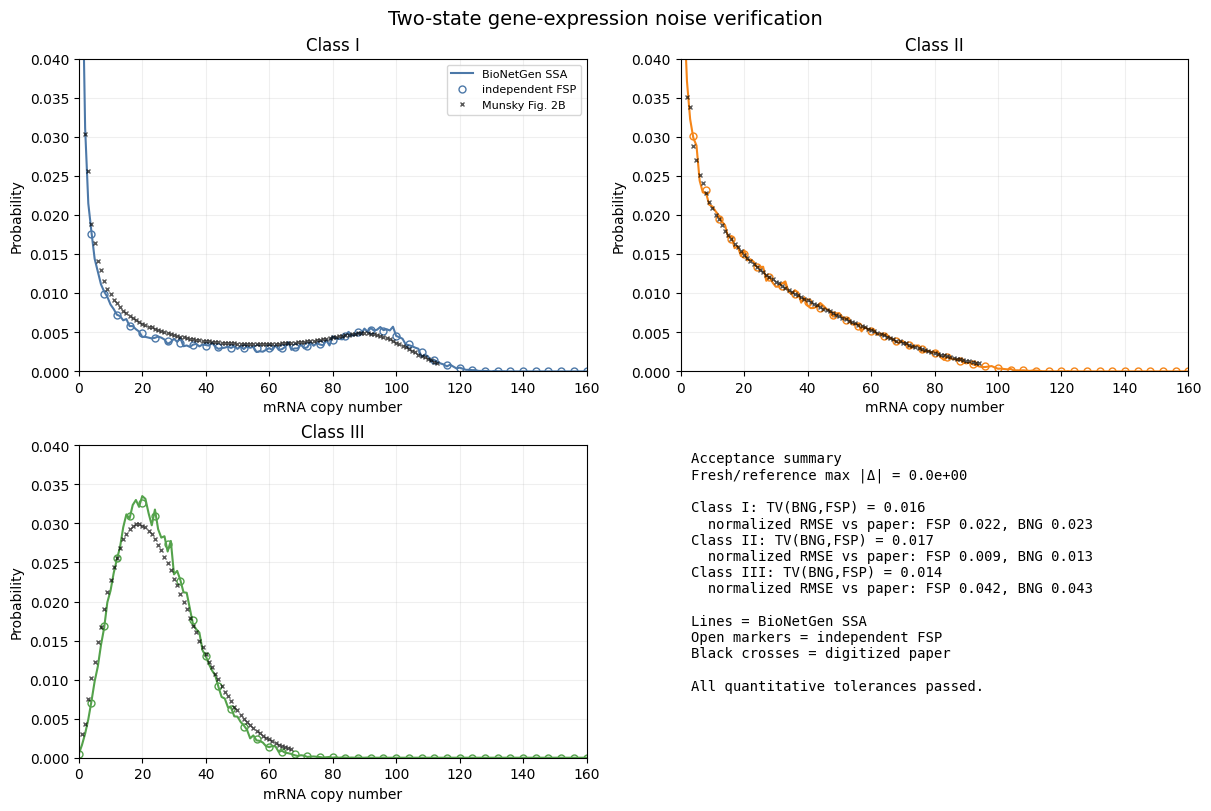

Saved /Users/l119605/Code/BNGL-Models/models/two_state_gene_expression_noise_munsky2012/verify_munsky2012.png


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
for axis, name in zip(axes.flat[:3], CLASSES):
    values = CLASSES[name]
    color = values["color"]
    axis.plot(M[:161], histograms[name][:161], color=color, lw=1.5, label="BioNetGen SSA")
    marker_indices = np.arange(0, 161, 4)
    axis.plot(
        marker_indices,
        fsp[name][marker_indices],
        "o",
        mfc="none",
        mec=color,
        ms=5,
        label="independent FSP",
    )
    subset = paper[paper["class"] == name]
    axis.plot(
        subset["mRNA_copy_number"],
        subset["probability"],
        "x",
        color="black",
        ms=3,
        alpha=0.65,
        label="Munsky Fig. 2B",
    )
    axis.set(title=f"Class {name}", xlim=(0, 160), ylim=(0, 0.04))
    axis.set_xlabel("mRNA copy number")
    axis.set_ylabel("Probability")
    axis.grid(alpha=0.2)
    if name == "I":
        axis.legend(fontsize=8)

summary_axis = axes.flat[3]
summary_axis.axis("off")
summary_lines = [
    "Acceptance summary",
    f"Fresh/reference max |Δ| = {reference_max_abs:.1e}",
    "",
]
for name in CLASSES:
    summary_lines.append(
        f"Class {name}: TV(BNG,FSP) = "
        f"{specification_metrics.loc[name, 'TV(BNG,FSP)']:.3f}"
    )
    summary_lines.append(
        f"  normalized RMSE vs paper: FSP "
        f"{reported_metrics.loc[name, 'FSP_normalized_RMSE']:.3f}, "
        f"BNG {reported_metrics.loc[name, 'BNG_normalized_RMSE']:.3f}"
    )
summary_lines.extend(
    [
        "",
        "Lines = BioNetGen SSA",
        "Open markers = independent FSP",
        "Black crosses = digitized paper",
        "",
        "All quantitative tolerances passed.",
    ]
)
summary_axis.text(0.02, 0.98, "\n".join(summary_lines), va="top", family="monospace")
fig.suptitle("Two-state gene-expression noise verification", fontsize=14)
fig.savefig(FIGURE_PATH, dpi=180)
plt.show()
print(f"Saved {FIGURE_PATH}")

## Conclusion

The fresh BioNetGen run exactly reproduces the committed fixed-seed reference.
All three BioNetGen stationary distributions pass the independent FSP distribution
and moment tolerances, and both calculations pass the quantitative comparison with
the digitized Fig. 2B curves. The model therefore reproduces the paper's defining
result: identical mean expression can conceal qualitatively distinct noise
phenotypes generated solely by promoter-switching time scales.